In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# load csv files
listings = pd.read_csv("/content/listings.csv")
calender = pd.read_csv("/content/calendar.csv")
reviews = pd.read_csv("/content/reviews.csv")

# data cleaning
#remove '$' and ',' from the price column in listings datasets
listings["price"] = (
    listings["price"]
    .astype(str)
    .str.replace("$","",regex=False)
    .str.replace(",","",regex= False)

)
# convert cleaned price column into numeric datatype
listings["price"] = pd.to_numeric(listings["price"],errors="coerce")
# do the same cleaning for calender dataset
calender["price"] = (
    calender["price"]
    .astype(str)
    .str.replace("$","",regex = False)
    .str.replace(",","",regex = False)

)
calender["price"] = pd.to_numeric(calender["price"], errors="coerce")

# convert available values
# t = available (1)
# f = not available(0)
calender["available"] = calender["available"].map({"t": 1, "f": 0})
# basic information of dataset
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
#print number od rows and columns
print("Listings shape :" ,listings.shape)
print("Calender shape :" , calender.shape)
print("Reviews shape :",reviews.shape)
# show columns
print("\nColumns")
print(listings.columns)
#missing values
print("\nMissing Values")
print(listings.isnull().sum())
# duplicates values
print("\nDuplicates Values")
print(listings.duplicated().sum())
# Statical summery
print("\nStastics")
print(
    listings[
        [
              "price",
              "accommodates",
              "bedrooms",
              "bathrooms"

    ]].describe()
)


DATASET INFORMATION
Listings shape : (3818, 92)
Calender shape : (1393570, 4)
Reviews shape : (84849, 6)

Columns
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'thumbnail_url', 'medium_url', 'picture_url',
       'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'street', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact'

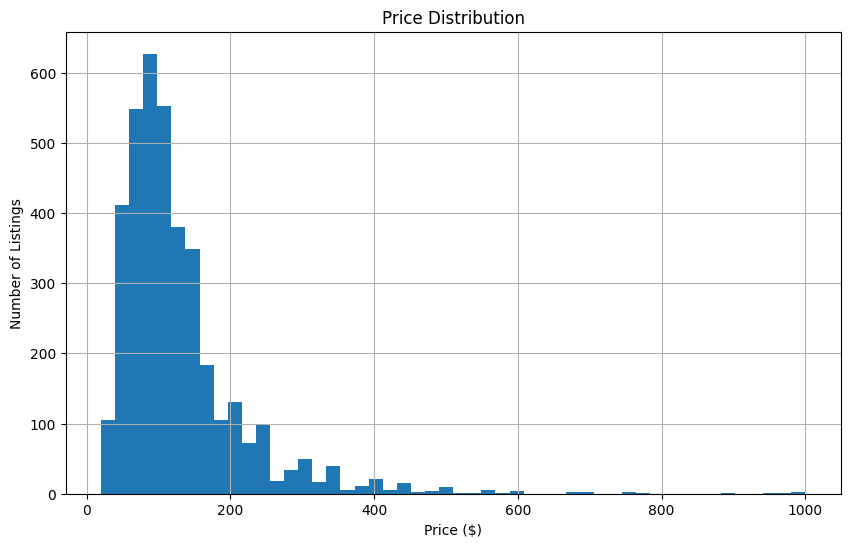

In [9]:
# Graph 1
plt.figure(figsize=(10,6))

# Histogram shows how listing prices are distributed
listings["price"].dropna().clip(upper=1000).hist(bins=50)

plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.grid(True)
plt.show()


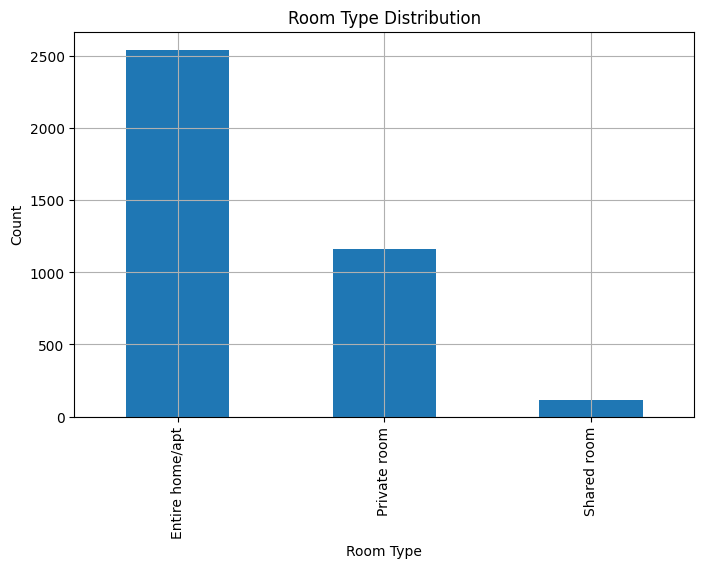

In [10]:
room_type = listings["room_type"].value_counts()

plt.figure(figsize=(8,5))

room_type.plot(kind="bar")

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.grid(True)
plt.show()

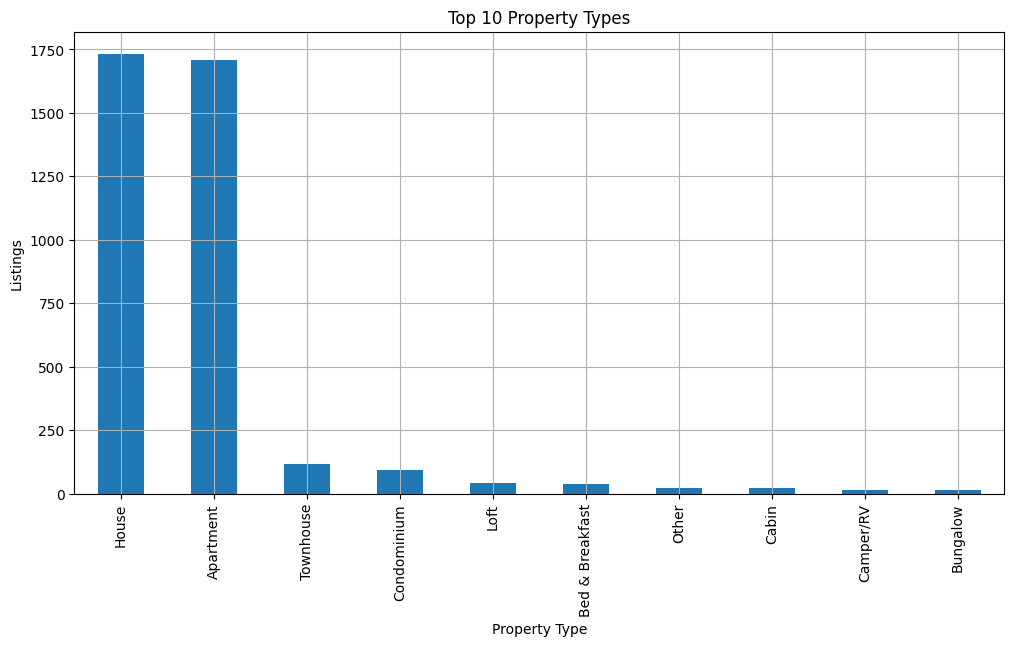

In [11]:
# Graph 3
# Property Type Distribution

property_type = (
    listings["property_type"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

property_type.plot(kind="bar")

plt.title("Top 10 Property Types")
plt.xlabel("Property Type")
plt.ylabel("Listings")
plt.grid(True)
plt.show()


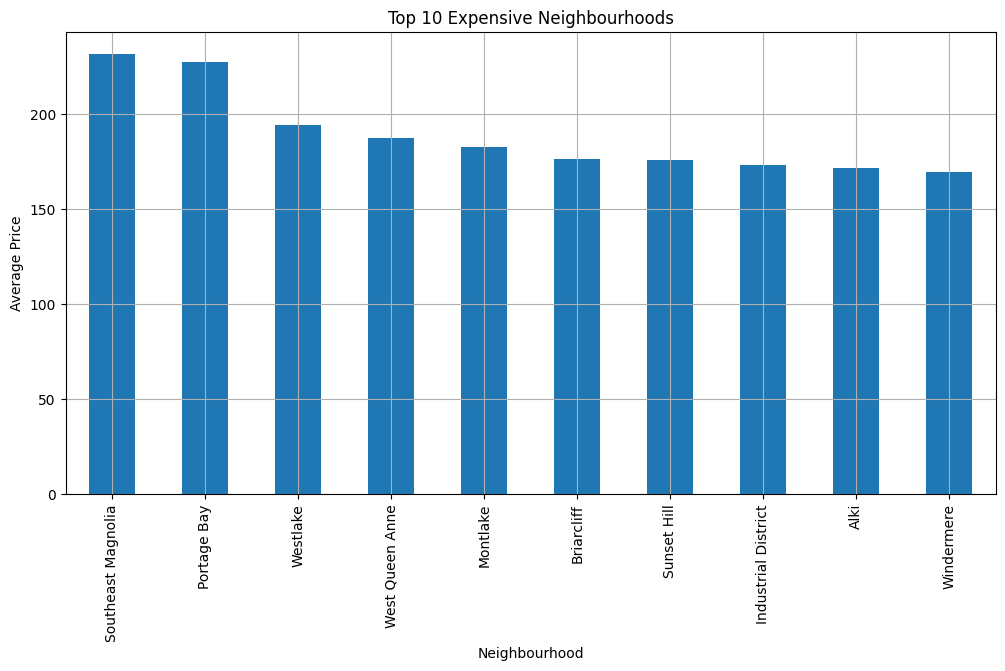

In [12]:
neighbourhood_price = (
    listings.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

neighbourhood_price.plot(kind="bar")

plt.title("Top 10 Expensive Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()



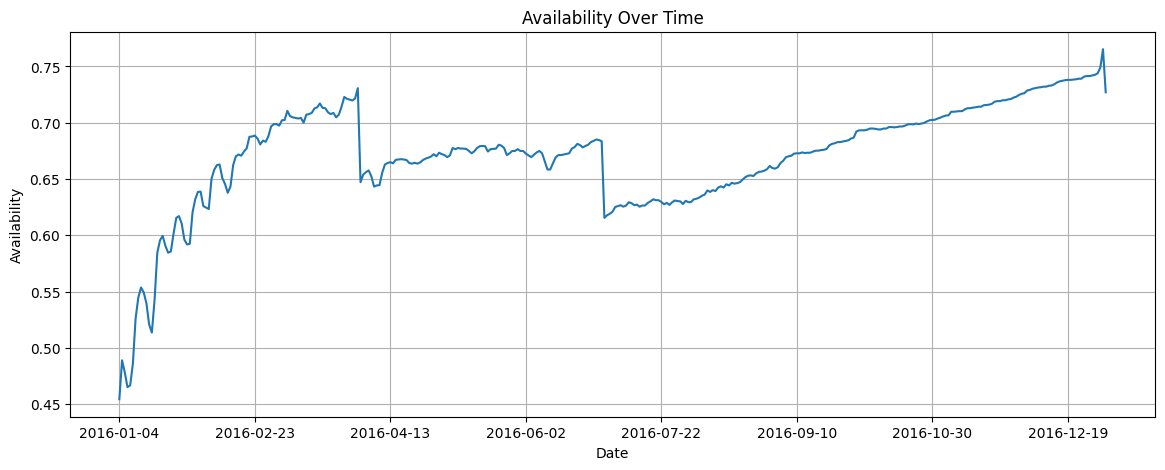

In [18]:
availability = calender.groupby("date")["available"].mean()

plt.figure(figsize=(14,5))

availability.plot()

plt.title("Availability Over Time")
plt.xlabel("Date")
plt.ylabel("Availability")
plt.grid(True)
plt.show()

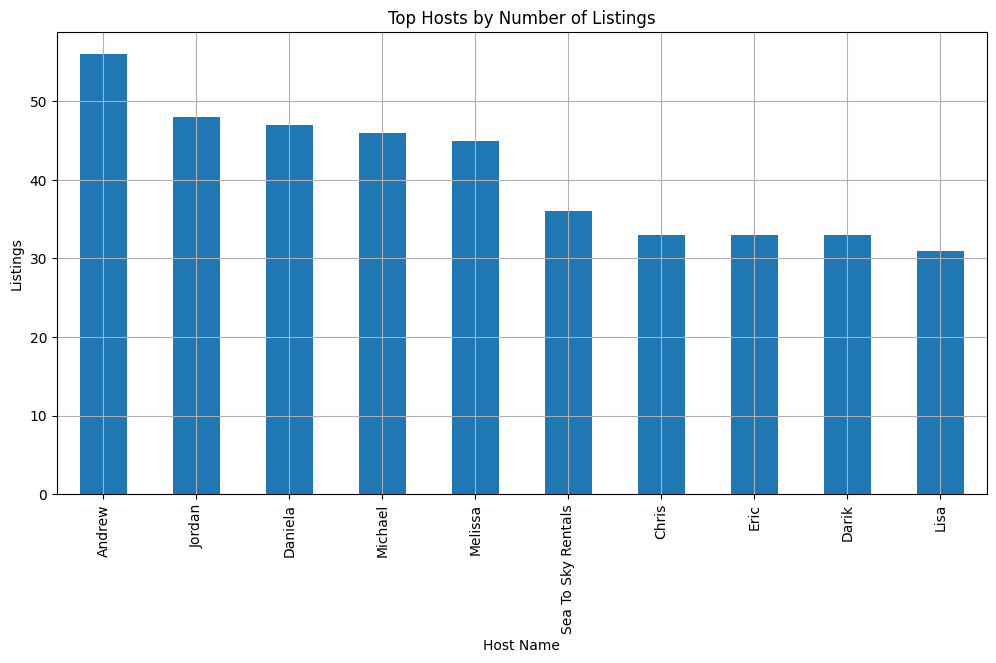

In [19]:
top_hosts = (
    listings.groupby("host_name")["id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_hosts.plot(kind="bar")

plt.title("Top Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Listings")
plt.grid(True)
plt.show()


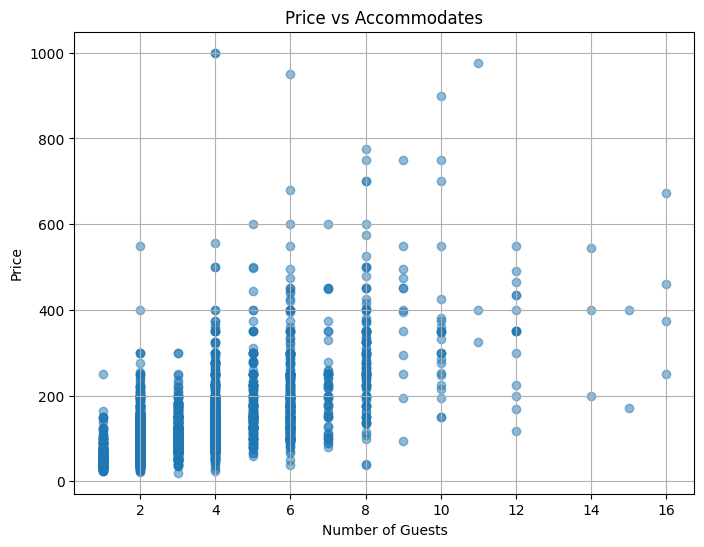

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    listings["accommodates"],
    listings["price"],
    alpha=0.5
)

plt.title("Price vs Accommodates")
plt.xlabel("Number of Guests")
plt.ylabel("Price")
plt.grid(True)
plt.show()

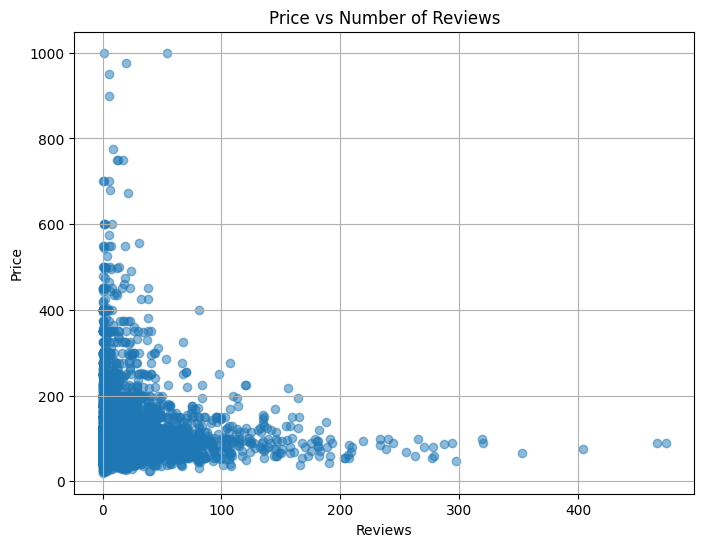

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    listings["number_of_reviews"],
    listings["price"],
    alpha=0.5
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Reviews")
plt.ylabel("Price")
plt.grid(True)
plt.show()


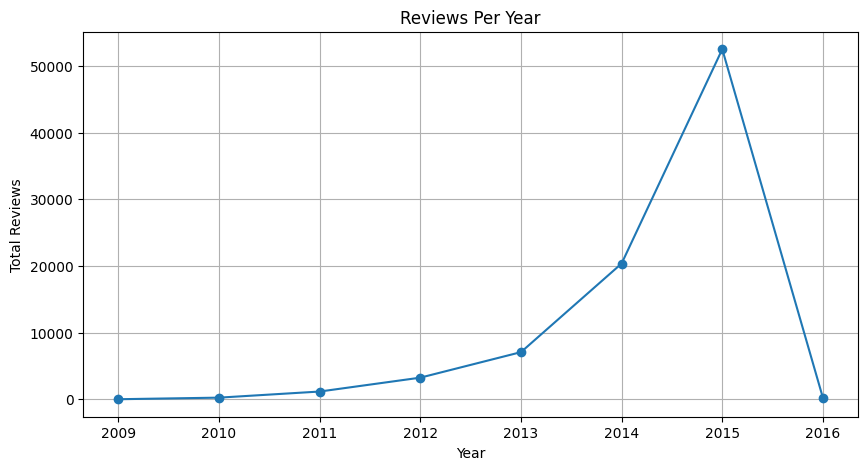

In [22]:
reviews["date"] = pd.to_datetime(reviews["date"])

reviews_year = (
    reviews.groupby(reviews["date"].dt.year)
    .size()
)

plt.figure(figsize=(10,5))

reviews_year.plot(marker="o")

plt.title("Reviews Per Year")
plt.xlabel("Year")
plt.ylabel("Total Reviews")
plt.grid(True)
plt.show()

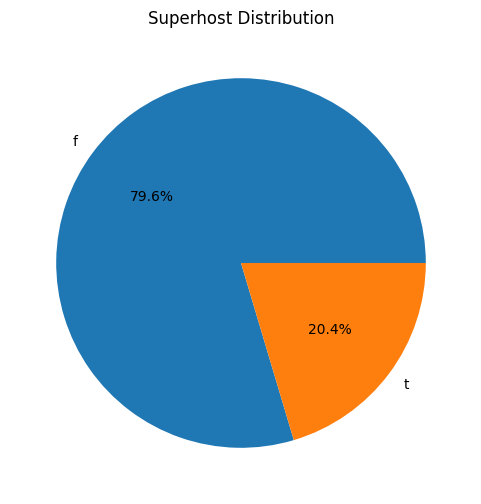

In [23]:
superhost = listings["host_is_superhost"].value_counts()

plt.figure(figsize=(6,6))

superhost.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Superhost Distribution")
plt.show()

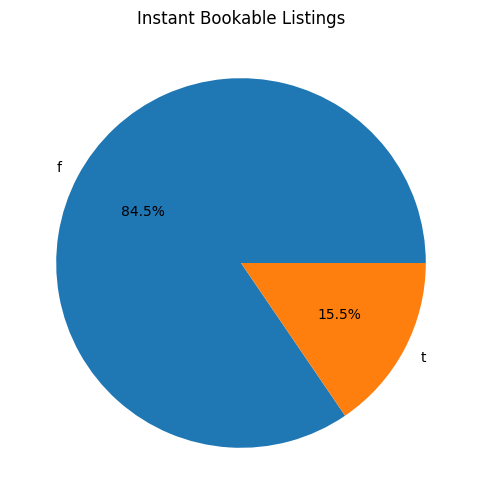

In [24]:
instant = listings["instant_bookable"].value_counts()

plt.figure(figsize=(6,6))

instant.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Instant Bookable Listings")
plt.show()



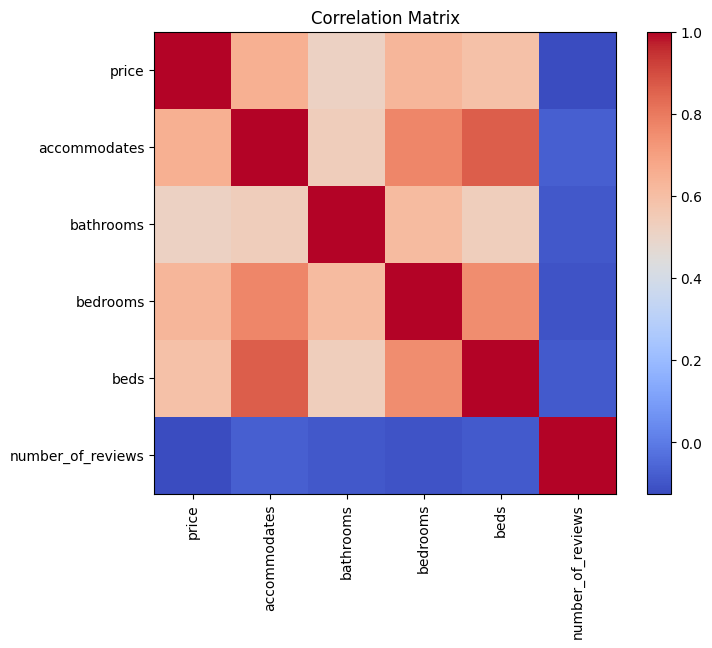

In [27]:
corr = listings[
    [
        "price",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "number_of_reviews"
    ]
].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()


In [28]:
# Final Insights
# ==========================

print("\nAverage Price")
print(round(listings["price"].mean(),2))

print("\nMedian Price")
print(round(listings["price"].median(),2))

print("\nHighest Price")
print(round(listings["price"].max(),2))

print("\nLowest Price")
print(round(listings["price"].min(),2))

print("\nTop 10 Expensive Neighbourhoods")
print(neighbourhood_price)

print("\nTop Hosts")
print(top_hosts)

print("\nRoom Type Distribution")
print(room_type)

print("\nProperty Type Distribution")
print(property_type)


Average Price
127.98

Median Price
100.0

Highest Price
1000.0

Lowest Price
20.0

Top 10 Expensive Neighbourhoods
neighbourhood_cleansed
Southeast Magnolia     231.705882
Portage Bay            227.857143
Westlake               194.470588
West Queen Anne        187.769231
Montlake               182.789474
Briarcliff             176.571429
Sunset Hill            176.055556
Industrial District    173.333333
Alki                   171.619048
Windermere             169.900000
Name: price, dtype: float64

Top Hosts
host_name
Andrew                56
Jordan                48
Daniela               47
Michael               46
Melissa               45
Sea To Sky Rentals    36
Chris                 33
Eric                  33
Darik                 33
Lisa                  31
Name: id, dtype: int64

Room Type Distribution
room_type
Entire home/apt    2541
Private room       1160
Shared room         117
Name: count, dtype: int64

Property Type Distribution
property_type
House              1733
A